# Ejercicion de programación - Regresión Logistica

En este ejercicio se implementa regresion logistica y se aplica a dos diferentes datasets.

In [16]:
# se utiliza para el manejo de rutas y directorios.
import os

# Calculo cientifico y vectorial para python
import numpy as np

# Librerias para graficar
from matplotlib import pyplot

# Modulo de optimización de scipy
from scipy import optimize

# Importar pandas para manejo de datos
import pandas as pd

# le dice a matplotlib que incruste gráficos en el cuaderno
%matplotlib inline

## 1 Regresion Logistica

En esta parte del ejercicio, creará un modelo de regresión logística para predecir si un estudiante será admitido en una universidad. Suponga que es el administrador de un departamento universitario y desea determinar las posibilidades de admisión de cada solicitante en función de sus resultados en dos exámenes. Tiene datos históricos de solicitantes anteriores que puede usar como un conjunto de capacitación para la regresión logística. Para cada ejemplo de capacitación, se tiene las calificaciones del solicitante en dos exámenes y la decisión de admisión. Su tarea es crear un modelo de clasificación que calcule la probabilidad de admisión de un solicitante en función de los puntajes de esos dos exámenes.

La siguiente celda cargará los datos y las etiquetas correspondientes:

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [17]:
# Cargar datos
# Las dos primeras columnas contienen la nota de dos examenes y la tercera columna
# contiene la etiqueta que indica si el alumno ingreso o no a la universidad.

# Usar pandas para cargar el CSV, que es más robusto para archivos CSV.
data_df = pd.read_csv('/content/drive/MyDrive/IA 1/datasets/Breast Cancer Wisconsin.csv', header=None)

# Establecer los nombres de las columnas desde la primera fila y luego eliminar esa fila
data_df.columns = data_df.iloc[0]
data_df = data_df[1:].reset_index(drop=True)

# Convertir la columna 'diagnosis' a valores numéricos (M=1, B=0)
data_df['diagnosis'] = data_df['diagnosis'].map({'M': 1, 'B': 0}).astype(int)

# Eliminar la columna 'id' que no es una característica predictiva
data_df = data_df.drop(columns=['id'])

# Todas las demás columnas deben ser numéricas para X
X_full = data_df.drop(columns=['diagnosis']).astype(float)
y_full = data_df['diagnosis']

# Para la visualización inicial con plotData, seleccionamos las primeras dos características numéricas relevantes:
# Por ejemplo, 'radius_mean' y 'texture_mean'
# Asegúrate de que los nombres de las columnas que usas aquí existan en tu dataset
X = X_full[['radius_mean', 'texture_mean']].values
y = y_full.values

print("Primeras 5 filas de X:\n", X[:5])
print("Primeras 5 filas de y:\n", y[:5])

Primeras 5 filas de X:
 [[17.99 10.38]
 [20.57 17.77]
 [19.69 21.25]
 [11.42 20.38]
 [20.29 14.34]]
Primeras 5 filas de y:
 [1 1 1 1 1]


### 1.1 Visualizar los datos

Antes de comenzar a implementar cualquier algoritmo de aprendizaje, siempre es bueno visualizar los datos si es posible. Mostramos los datos en una gráfica bidimensional llamando a la función `plotData`. Se completará el código en `plotData` para que muestre una figura donde los ejes son los dos puntajes de los dos examenes, los ejemplos positivos y negativos se muestran con diferentes marcadores.

In [18]:
def plotData(X, y):
    # Gragica los puntos de datos X y y en una nueva figura. Grafica los puntos de datos con * para los positivos y
    # o para los negativos.

    # Crea una nueva figura
    fig = pyplot.figure()

    # Find Indices of Positive and Negative Examples
    pos = y == 1
    neg = y == 0

    # Plot Examples
    pyplot.plot(X[pos, 0], X[pos, 1], 'k*', lw=2, ms=10)
    pyplot.plot(X[neg, 0], X[neg, 1], 'ko', mfc='y', ms=8, mec='k', mew=1)


Se llama a la función implementada para mostrar los datos cargados:

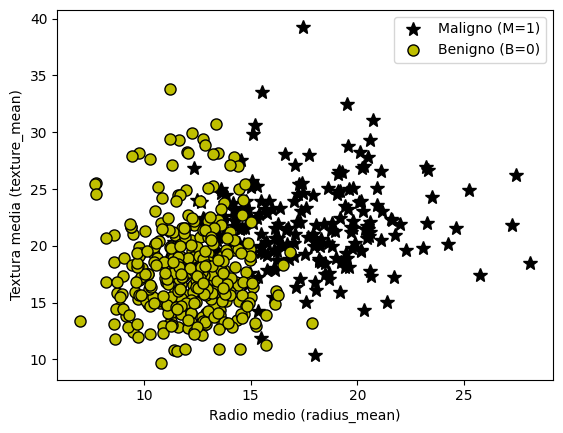

In [19]:
plotData(X, y)
# adiciona etiquetas para los ejes
pyplot.xlabel('Radio medio (radius_mean)')
pyplot.ylabel('Textura media (texture_mean)')
pyplot.legend(['Maligno (M=1)', 'Benigno (B=0)'])
pass

<a id="section1"></a>
### 1.2 Implementacion

#### 1.2.1 Fución Sigmoidea

La hipotesis para la regresión logistica se define como:

$$ h_\theta(x) = g(\theta^T x)$$

donde la función $g$ es la función sigmoidea. La función sigmoidea se define como:

$$g(z) = \frac{1}{1+e^{-z}}$$.

Los resultados que debe generar la funcion sigmoidea para valores positivos amplios de `x`, deben ser cercanos a 1, mientras que para valores negativos grandes, la sigmoide debe generar valores cercanos 0. La evaluacion de `sigmoid(0)` debe dar un resultado exacto de 0.5. Esta funcion tambien debe poder trabajar con vectores y matrices.

In [20]:
def calcularSigmoide(z):
    # Calcula la sigmoide de una entrada z
    # convierte la intrada a un arreglo numpy
    z = np.array(z)

    g = np.zeros(z.shape)

    g = 1 / (1 + np.exp(-z))

    return g

Se calcula el valor de la sigmoide aplicando la funcion sigmoid con `z=0`, se debe obtener un resultado de 0.5. RE recomienda experimentar con otros valores de `z`.

In [21]:
# Prueba la implementacion de la funcion sigmoid
z = [-9099991, 309000000, 0]
g = calcularSigmoide(z)

print('g(', z, ') = ', g)

g( [-9099991, 309000000, 0] ) =  [0.  1.  0.5]


/tmp/ipykernel_3655/3890281146.py:8: RuntimeWarning: overflow encountered in exp
  g = 1 / (1 + np.exp(-z))


<a id="section2"></a>
#### 1.2.2 Función de Costo y Gradiente

Se implementa la funcion cost y gradient, para la regresión logistica. Antes de continuar es importante agregar el termino de intercepcion a X.

In [23]:
from sklearn.preprocessing import StandardScaler

# Configurar la matriz adecuadamente, y agregar una columna de unos que corresponde al termino de intercepción.

# Usar X_full y y_full que contienen todas las características
m, n = X_full.shape

# Inicializar el StandardScaler
scaler = StandardScaler()

# Escalar las características en X_full.values para evitar errores de tipo de nombre de columna.
X_scaled = scaler.fit_transform(X_full.values)

# Agraga el termino de intercepción a X_scaled
X = np.concatenate([np.ones((m, 1)), X_scaled], axis=1)
y = y_full.values # Asegurarse de que y sea un numpy array

print("Primeras 5 filas de X (con intercepto y escalado):", X[:5])
print("Primeras 5 filas de y:", y[:5])

Primeras 5 filas de X (con intercepto y escalado): [[ 1.00000000e+00  1.09706398e+00 -2.07333501e+00  1.26993369e+00
   9.84374905e-01  1.56846633e+00  3.28351467e+00  2.65287398e+00
   2.53247522e+00  2.21751501e+00  2.25574689e+00  2.48973393e+00
  -5.65265059e-01  2.83303087e+00  2.48757756e+00 -2.14001647e-01
   1.31686157e+00  7.24026158e-01  6.60819941e-01  1.14875667e+00
   9.07083081e-01  1.88668963e+00 -1.35929347e+00  2.30360062e+00
   2.00123749e+00  1.30768627e+00  2.61666502e+00  2.10952635e+00
   2.29607613e+00  2.75062224e+00  1.93701461e+00             nan]
 [ 1.00000000e+00  1.82982061e+00 -3.53632408e-01  1.68595471e+00
   1.90870825e+00 -8.26962447e-01 -4.87071673e-01 -2.38458552e-02
   5.48144156e-01  1.39236330e-03 -8.68652457e-01  4.99254601e-01
  -8.76243603e-01  2.63326966e-01  7.42401948e-01 -6.05350847e-01
  -6.92926270e-01 -4.40780058e-01  2.60162067e-01 -8.05450380e-01
  -9.94437403e-02  1.80592744e+00 -3.69203222e-01  1.53512599e+00
   1.89048899e+00 -3.756

/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


La funcion de costo en una regresión logistica es:

$$ J(\theta) = \frac{1}{m} \sum_{i=1}^{m} \left[ -y^{(i)} \log\left(h_\theta\left( x^{(i)} \right) \right) - \left( 1 - y^{(i)}\right) \log \left( 1 - h_\theta\left( x^{(i)} \right) \right) \right]$$

y el gradiente del costo es un vector de la misma longitud como $\theta$ donde el elemento $j^{th}$ (para $j = 0, 1, \cdots , n$) se define como:

$$ \frac{\partial J(\theta)}{\partial \theta_j} = \frac{1}{m} \sum_{i=1}^m \left( h_\theta \left( x^{(i)} \right) - y^{(i)} \right) x_j^{(i)} $$

Si bien este gradiente parece idéntico al gradiente de regresión lineal, la fórmula es diferente porque la regresión lineal y logística tienen diferentes definiciones de $h_\theta(x)$.
<a id="costFunction"></a>

In [25]:
def calcularCosto(theta, X, y):
    # Inicializar algunos valores utiles
    m = y.size  # numero de ejemplos de entrenamiento

    J = 0
    h = calcularSigmoide(X @ theta) # Correcto: usa X @ theta
    J = (1 / m) * np.sum(-y * np.log(h) - (1 - y) * np.log(1 - h)) # Correcto: usa multiplicacion elemento a elemento

    return J

In [26]:
def descensoGradiente(theta, X, y, alpha, num_iters):
    # Inicializa algunos valores
    m = y.shape[0] # numero de ejemplos de entrenamiento

    # realiza una copia de theta, el cual será acutalizada por el descenso por el gradiente
    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        h = calcularSigmoide(X @ theta) # Correcto: usa X @ theta
        # Gradiente vectorizado: X.T @ (h - y)
        theta = theta - (alpha / m) * (X.T @ (h - y))

        J_history.append(calcularCosto(theta, X, y))
    return theta, J_history

theta calculado por el descenso por el gradiente: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan]


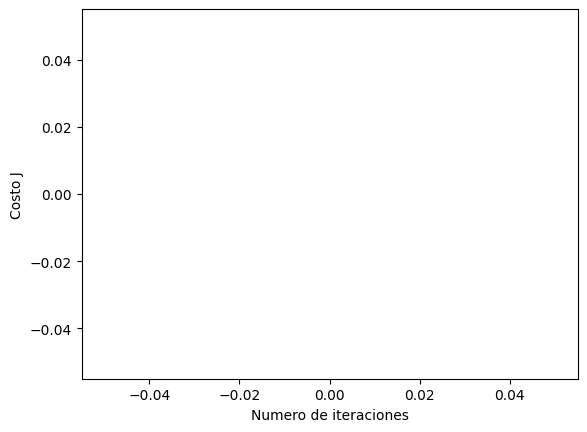

In [27]:
# Elegir algun valor para alpha (probar varias alternativas)
alpha = 0.01  # Reducir el learning rate
num_iters = 500000

# El numero de elementos en theta debe ser (n + 1) donde n es el numero de caracteristicas en X_full
n_features = X.shape[1] # X ahora tiene la columna de unos y las caracteristicas escaladas
theta = np.zeros(n_features)

# inicializa theta y ejecuta el descenso por el gradiente
theta, J_history = descensoGradiente(theta, X, y, alpha, num_iters)

# Grafica la convergencia del costo
pyplot.plot(np.arange(len(J_history)), J_history, lw=2)
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')

# Muestra los resultados del descenso por el gradiente
print('theta calculado por el descenso por el gradiente: {:s}'.format(str(theta)))

In [ ]:
print(J_history[-1])

0.28790343361822807


In [ ]:
def predecir(theta, X):
    # Predice si la etiqueta es 0 o 1 usando el umbral de 0.5
    p = calcularSigmoide(X.dot(theta.T))
    return (p >= 0.5).astype(int)

# Ejemplo de predicción para una nueva instancia (se necesitan todas las características)
# Para este dataset, esto sería más complejo ya que X tiene 31 características + intercepto.
# Por simplicidad y para demostrar el flujo, usamos un ejemplo generico si el usuario lo solicita,
# pero para una prediccion real, se necesitarían valores para todas las caracteristicas.
# Por ahora, calculamos la precisión sobre el conjunto de entrenamiento.

# Predecir sobre el conjunto de entrenamiento
p = predecir(theta, X)

# Calcular la precisión
accuracy = np.mean(p == y) * 100
print('Precisión de entrenamiento: {:.2f} %'.format(accuracy))

Precisión de entrenamiento: 62.74 %


In [ ]:
# Este cell no es necesario, ya que la precisión se calcula en el cell anterior.
# Se puede eliminar o comentar si se desea.
# Manteniéndolo por si el usuario quiere probar con valores específicos en el futuro.